<a href="https://colab.research.google.com/github/Rijwan94/DS_Pyhton_M2/blob/main/Mid_Course_Applied_Statistics_Project_Rijwan_Shaikh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Purchase Behavior Analysis using Descriptive Statistics

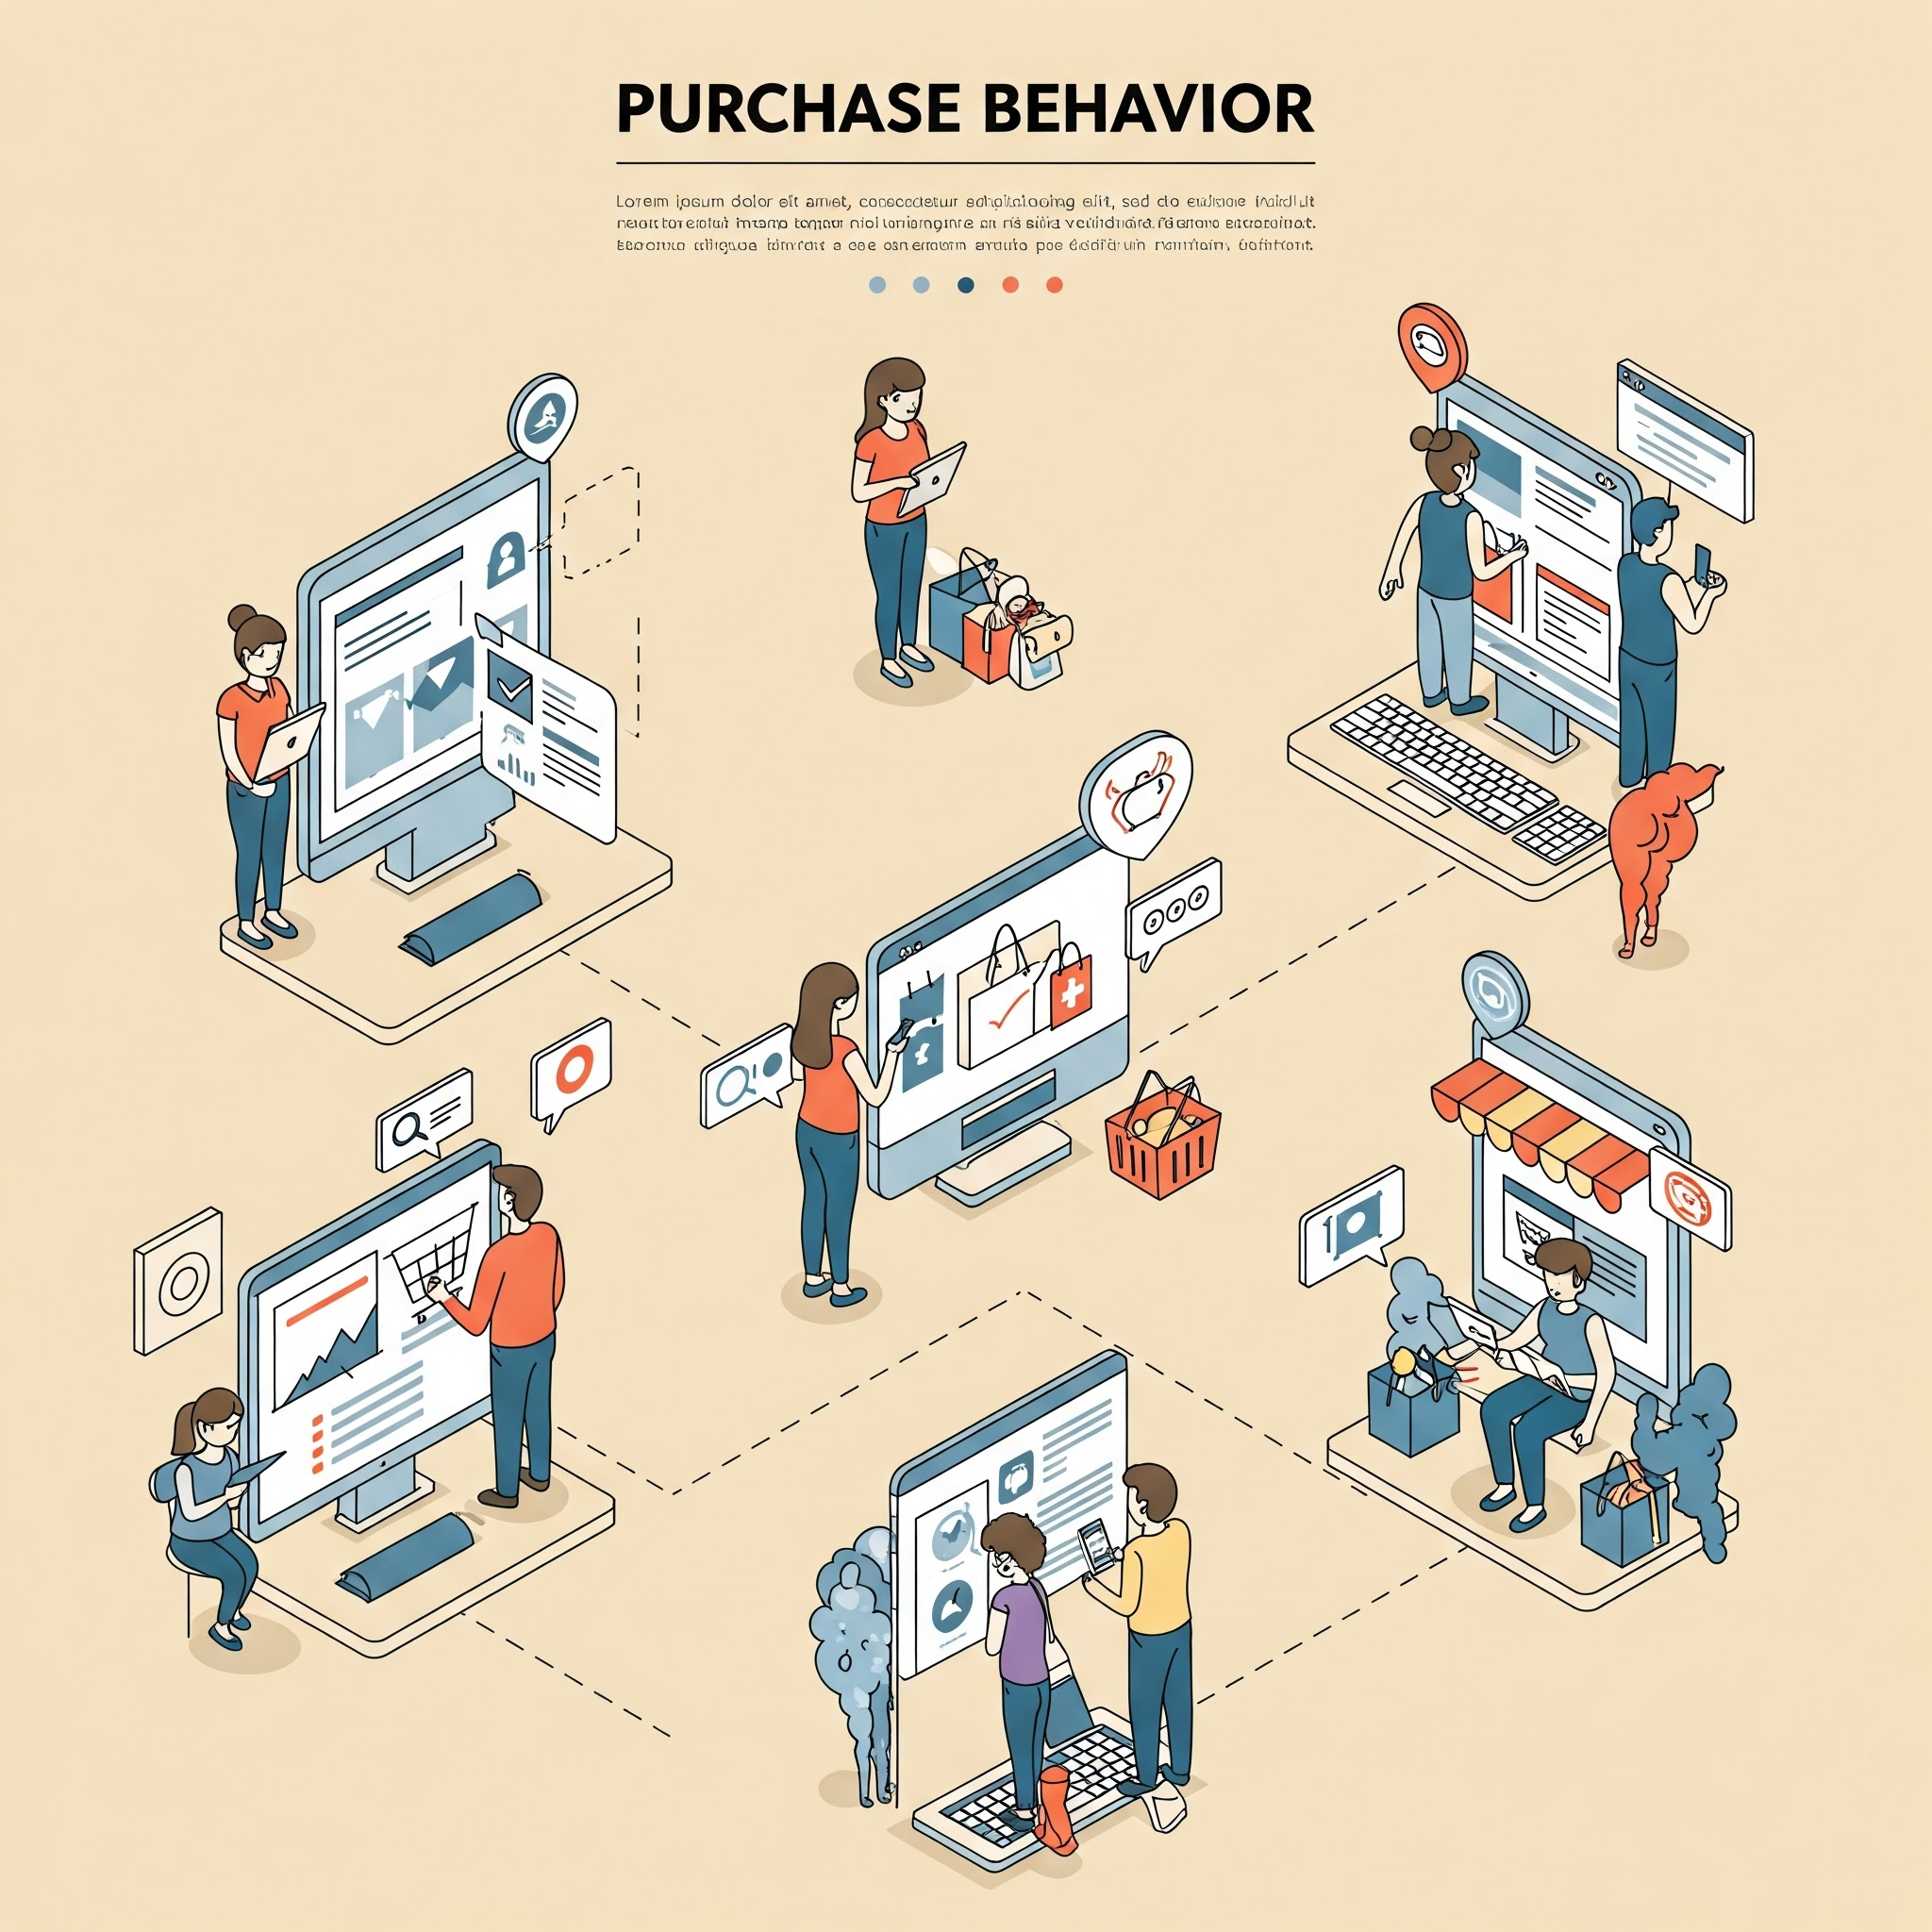

##Problem Statement

🔍 **Problem Statement**:

Welcome to the Probability and Statistics project! 📊🔍 In this exciting journey, you'll get the chance to apply the concepts you've learned in probability theory and statistics to analyze a real-world dataset. This project is your opportunity to dive deep into the world of data analysis and gain practical experience with the tools and techniques you've been learning. 🚀

🎯 **Objective**:

Your mission is to analyze the provided dataset containing customer information and purchasing behavior to make informed decisions. Your goal is to identify patterns, trends, and correlations that will help your company optimize its marketing efforts and increase offer acceptance rates. 🎉

##About the Dataset

## **Load the of Dataset**

Importing Required Libraries

In [ ]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import binom, norm
from scipy.stats import poisson
from scipy.stats import expon
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew, kurtosis, shapiro

Connect Drive

In [ ]:
#Connect drive

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Load CSV File / Dataset

In [ ]:
#Load CSV File
PBA_df = pd.read_csv('/content/drive/MyDrive/Data Science/5. Applied Statistics/Mid Course/Superstore Marketing Data - Sheet1.csv', encoding='latin-1')




Here's the link to the [dataset](https://docs.google.com/spreadsheets/d/12ln9iTNcVNOMYi_AU-OczKpa_KIP8XyVbsjk81Na8Yk/edit?usp=sharing)


This data was gathered during last year's campaign.
Data description is as follows;

1. Response (target) - 1 if customer accepted the offer in the last campaign, 0 otherwise
1. ID - Unique ID of each customer
1. Year_Birth - Age of the customer
1. Complain - 1 if the customer complained in the last 2 years
1. Dt_Customer - date of customer's enrollment with the company
1. Education - customer's level of education
1. Marital - customer's marital status
1. Kidhome - number of small children in customer's household
1. Teenhome - number of teenagers in customer's household
1. Income - customer's yearly household income
1. MntFishProducts - the amount spent on fish products in the last 2 years
1. MntMeatProducts - the amount spent on meat products in the last 2 years
1. MntFruits - the amount spent on fruits products in the last 2 years
1. MntSweetProducts - amount spent on sweet products in the last 2 years
1. MntWines - the amount spent on wine products in the last 2 years
1. MntGoldProds - the amount spent on gold products in the last 2 years
1. NumDealsPurchases - number of purchases made with discount
1. NumCatalogPurchases - number of purchases made using catalog (buying goods to be shipped through the mail)
1. NumStorePurchases - number of purchases made directly in stores
1. NumWebPurchases - number of purchases made through the company's website
1. NumWebVisitsMonth - number of visits to company's website in the last month
1. Recency - number of days since the last purchase





Dataframe PBA_df (Purchase Behaviour Analysis Data Frame)

In [ ]:
# Dataframe View
PBA_df

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,...,111,189,218,1,4,4,6,1,1,0
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,...,7,0,37,1,7,3,7,5,1,0
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,...,15,2,30,1,3,2,5,2,0,0
3,1386,1967,Graduation,Together,32474.0,1,1,########,0,10,...,0,0,0,1,1,0,2,7,0,0
4,5371,1989,Graduation,Single,21474.0,1,0,########,0,6,...,11,0,34,2,3,1,2,7,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,66476.0,0,1,########,99,372,...,47,48,78,2,5,2,11,4,0,0
2236,5263,1977,2n Cycle,Married,31056.0,1,0,1/22/2013,99,5,...,3,8,16,1,1,0,3,8,0,0
2237,22,1976,Graduation,Divorced,46310.0,1,0,########,99,185,...,15,5,14,2,6,1,5,8,0,0
2238,528,1978,Graduation,Married,65819.0,0,0,11/29/2012,99,267,...,149,165,63,1,5,4,10,3,0,0


In [ ]:
# Dataset Rows & Columns count
PBA_df.shape

(2240, 22)

In [ ]:
# Dataset Info
PBA_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

##Task 1 - Basic CleanUp

- **Clean and preprocess the dataset (handling missing values, data types, etc.).**

- **Analyze the distribution of customer demographics (age, education, marital status) using descriptive statistics and visualizations.**

In [ ]:
# Missing Values/Null Values Count
PBA_df.isnull().sum()

,0
Id,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


###Handling missing values, data types, etc.

In [ ]:
#Check which method should be followed to Clean 'Income' Column.

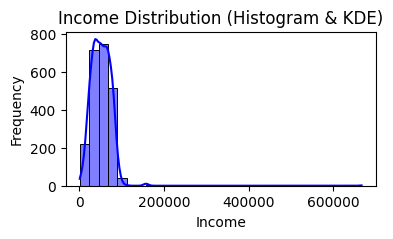

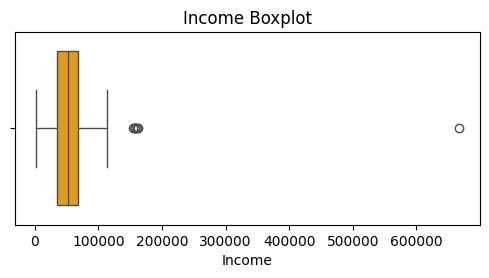

Skewness: 6.80
Kurtosis: 161.04
Shapiro-Wilk Test p-value: 0.0000
Income data is skewed (not normally distributed).
Since skewness is high, use MEDIAN for missing value imputation.


In [ ]:
# 1. Plot Histogram & KDE
plt.figure(figsize=(4, 2))
sns.histplot(PBA_df["Income"], kde=True, bins=30, color="blue")
plt.title("Income Distribution (Histogram & KDE)")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

# 2. Boxplot for Outliers & Skewness
plt.figure(figsize=(6, 2.5))
sns.boxplot(x=PBA_df["Income"], color="orange")
plt.title("Income Boxplot")
plt.show()

# 3. Calculate Skewness & Kurtosis
income_skew = skew(PBA_df["Income"].dropna())  # Drop NaN to avoid errors
income_kurt = kurtosis(PBA_df["Income"].dropna())

print(f"Skewness: {income_skew:.2f}")
print(f"Kurtosis: {income_kurt:.2f}")

# 4. Shapiro-Wilk Test for Normality
shapiro_test = shapiro(PBA_df["Income"].dropna().sample(500) if len(PBA_df) > 500 else PBA_df["Income"].dropna())
p_value = shapiro_test.pvalue

print(f"Shapiro-Wilk Test p-value: {p_value:.4f}")
if p_value > 0.05:
    print("Income data appears to be normally distributed.")
else:
    print("Income data is skewed (not normally distributed).")

# Decision:
if abs(income_skew) < 0.5:
    print("Since skewness is low, use MEAN for missing value imputation.")
else:
    print("Since skewness is high, use MEDIAN for missing value imputation.")


In [ ]:
#Replaces all null (NaN) values in Income with the median.
PBA_df['Income'].fillna(PBA_df['Income'].median(), inplace=True)

<ipython-input-8-5a52ca20cfab>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  PBA_df['Income'].fillna(PBA_df['Income'].median(), inplace=True)


In [ ]:
#check isnull for Income
PBA_df['Income'].isnull().sum()

0